<a href="https://colab.research.google.com/github/snig-17/COMP0014/blob/main/COMP0014_Final_Coursework_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Directory 'Fashion_MNIST' already exists. Skipping download.


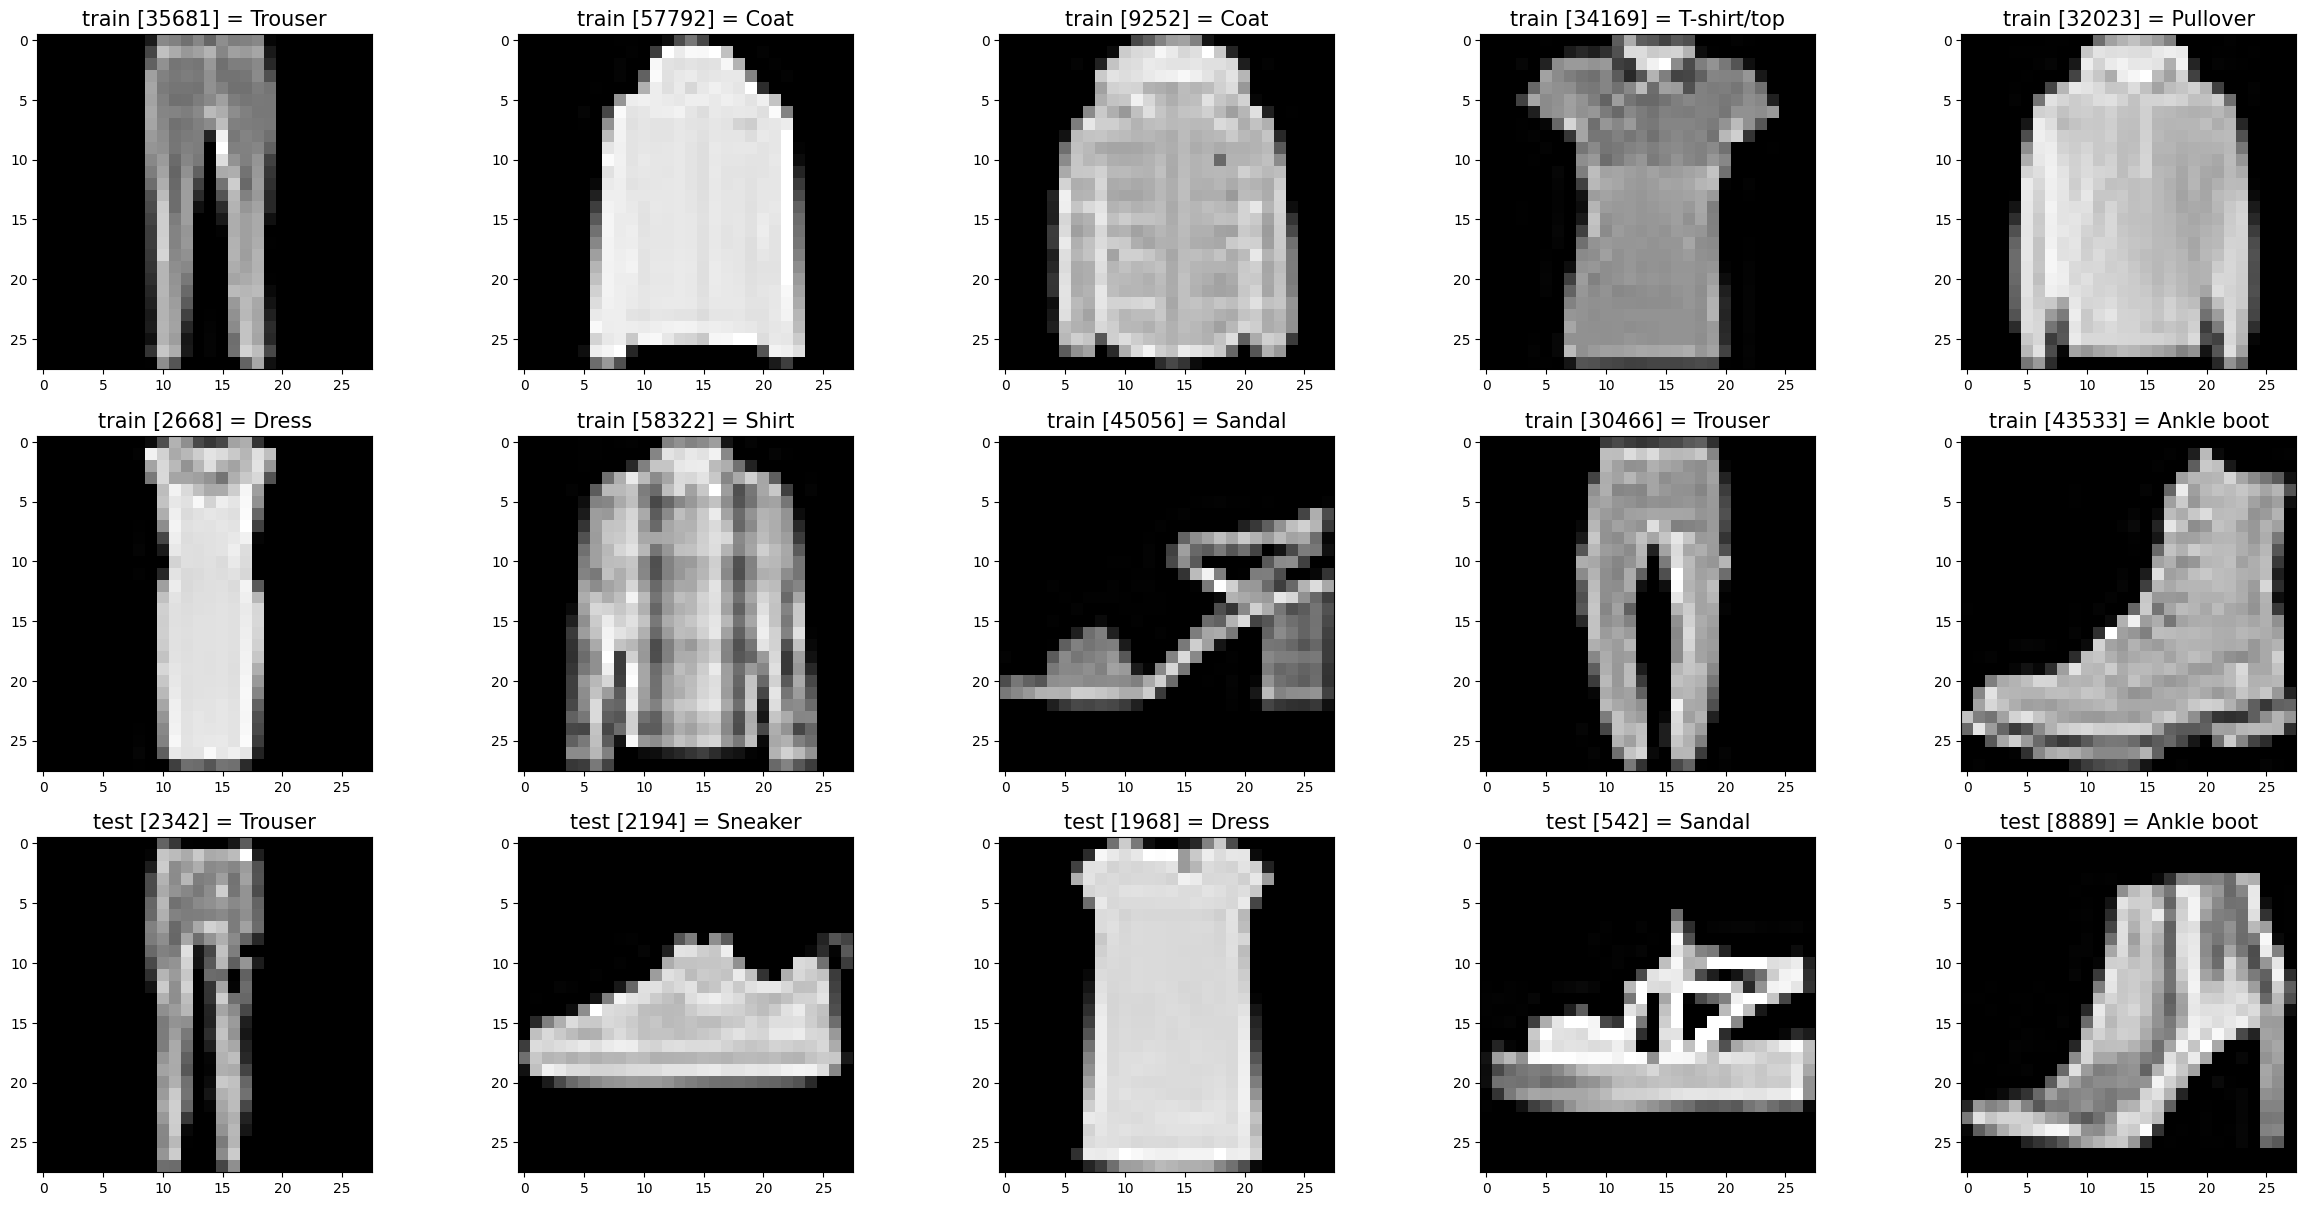

In [17]:
# Import necessary libraries
import numpy as np
import struct
from array import array
import os.path
import random
import matplotlib.pyplot as plt
import time
%matplotlib inline


# Fashion MNIST class labels mapping
fashion_labels = {
    0: 'T-shirt/top', 1: 'Trouser',  2: 'Pullover',
    3: 'Dress',        4: 'Coat',     5: 'Sandal',
    6: 'Shirt',        7: 'Sneaker',  8: 'Bag',
    9: 'Ankle boot'
}

# Custom MNIST Data Loader Class to read image and label files
class MnistDataloader(object):
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8)) # Read magic number and size
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = np.array(array("B", file.read()), dtype=np.uint8) # Read labels as byte array

        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16)) # Read magic number, size, rows, cols
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read()) # Read image data as byte array
            # Reshape image data into a 2D array (size x (rows*cols))
            images = np.array(image_data, dtype=np.uint8).reshape(size, rows * cols)

        return images, labels

    def load_data(self):
        # Load training and test images/labels
        x_train, y_train = self.read_images_labels(
            self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(
            self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


# Helper function to display a list of images with their titles
def show_images(images, title_texts):
    cols = 5 # Number of columns for displaying images
    rows = int(len(images) / cols) + 1 # Calculate number of rows
    plt.figure(figsize=(30, 20)) # Set figure size
    index = 1
    for x in zip(images, title_texts):
        image = x[0].reshape(28, 28) # Reshape 1D image array to 28x28 for display
        title_text = x[1]
        plt.subplot(rows, cols, index) # Create subplot
        plt.imshow(image, cmap=plt.cm.gray) # Display image in grayscale
        if title_text != '':
            plt.title(title_text, fontsize=15) # Set title for the image
        index += 1
    plt.show() # Show the plot


# Define the path to the Fashion_MNIST dataset folder
input_path = 'Fashion_MNIST' # Correct path for data files
training_images_filepath = os.path.join(input_path, 'train-images-idx3-ubyte')
training_labels_filepath = os.path.join(input_path, 'train-labels-idx1-ubyte')
test_images_filepath     = os.path.join(input_path, 't10k-images-idx3-ubyte')
test_labels_filepath     = os.path.join(input_path, 't10k-labels-idx1-ubyte')

# Load Fashion MNIST dataset using the custom dataloader
fashion_dataloader = MnistDataloader(
    training_images_filepath, training_labels_filepath,
    test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = fashion_dataloader.load_data()

# Display random sample of training and test images with clothing labels
image_list = []
title_list = []

# Select 10 random training images
for i in range(0, 10):
    r = random.randint(1, 60000)
    image_list.append(x_train[r])
    title_list.append('train [{}] = {}'.format(r, fashion_labels[y_train[r]]))

# Select 5 random test images
for i in range(0, 5):
    r = random.randint(1, 10000)
    image_list.append(x_test[r])
    title_list.append('test [{}] = {}'.format(r, fashion_labels[y_test[r]]))

# Show the selected images
show_images(image_list, title_list)

In [18]:
from sklearn import svm, metrics
from sklearn.model_selection import train_test_split
import datetime

# Normalise pixel values to a range of 0 to 1
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Create a mini training set (10% of the original) for hyperparameter tuning
# This speeds up grid search by working with a smaller dataset
x_train_mini, _, y_train_mini, _ = train_test_split(
    x_train, y_train, test_size=0.90, random_state=666)

In [19]:
# Define C values for the Linear kernel
C_values = [0.1, 1, 10]
linear_results = []

# Perform grid search for the Linear kernel
for C in C_values:
    # Initialize SVM classifier with linear kernel and current C value
    clf = svm.SVC(kernel='linear', C=C)

    start = time.time() # Start time for training
    clf.fit(x_train_mini, y_train_mini) # Train the classifier on the mini dataset
    train_time = time.time() - start # Calculate training time

    train_acc = clf.score(x_train_mini, y_train_mini) # Calculate training accuracy
    test_acc  = clf.score(x_test, y_test) # Calculate test accuracy

    # Store the results for the current C value
    linear_results.append({
        'C': C,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'overfit_gap': train_acc - test_acc,
        'time': train_time
    })

In [20]:
# Helper function to find the best model configuration based on test accuracy
def get_best(results):
    # The best model is considered the one with the highest test accuracy
    return max(results, key=lambda x: x['test_acc'])

# Get the best configuration found for the Linear kernel
best_linear  = get_best(linear_results)
#best_rbf     = get_best(rbf_results)
#best_poly    = get_best(poly_results)
#best_sigmoid = get_best(sigmoid_results)

# Print the best Linear kernel configuration
print('Best Linear: ',  best_linear)
#print('Best RBF: ',     best_rbf)
#print('Best Poly: ',    best_poly)
#print('Best Sigmoid: ', best_sigmoid)

Best Linear:  {'C': 0.1, 'train_acc': 0.921, 'test_acc': 0.8403, 'overfit_gap': 0.0807, 'time': 4.28298020362854}


In [21]:
# Initialize the SVM classifier with the best hyperparameters found for the Linear kernel
classifier = svm.SVC(
    kernel='linear',
    C=best_linear['C'], # Use the optimal C value from the grid search
)

Started training at 2026-03-16 18:55:58.514551
Training complete. Elapsed time: 0:00:03.610160
Prediction elapsed time: 0:00:20.552578


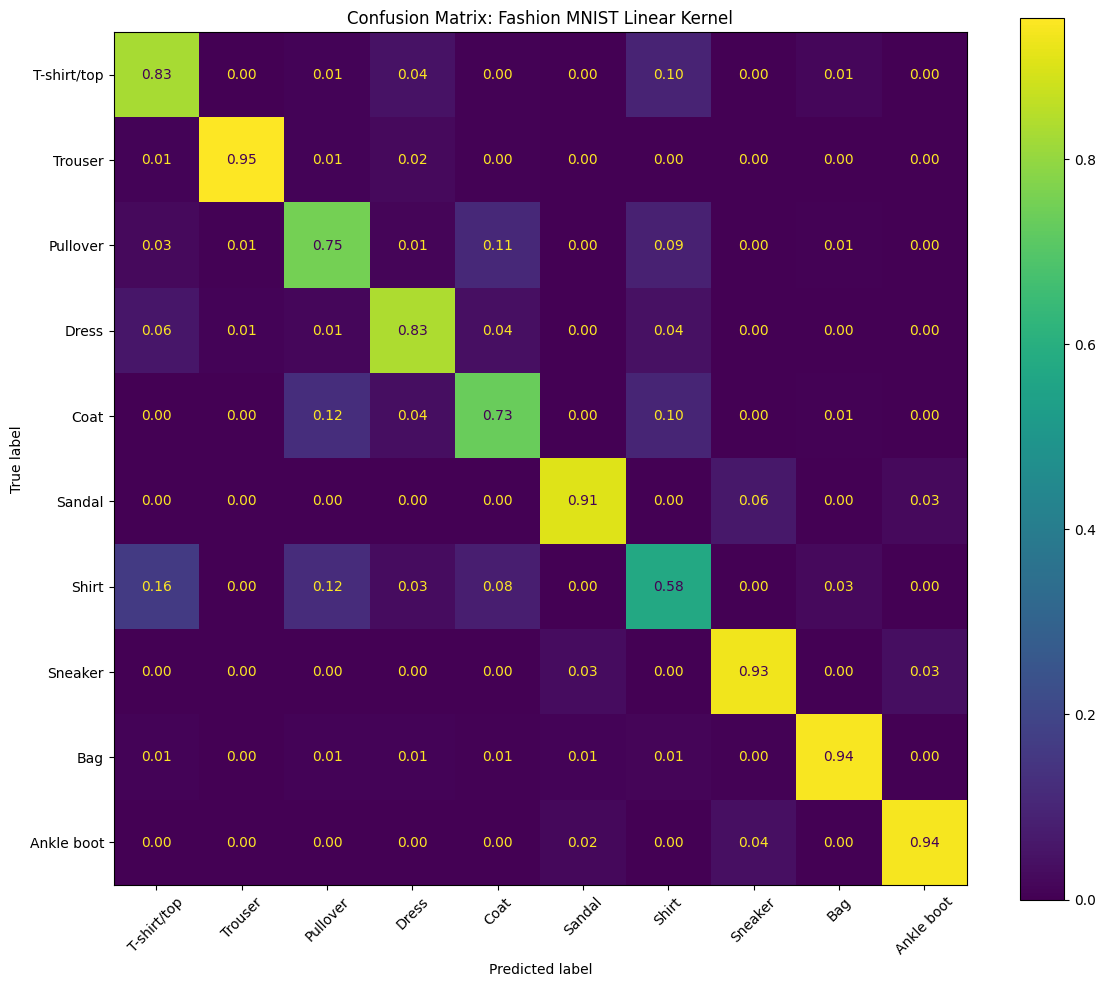

Train Accuracy:  0.9210
Test Accuracy:   0.8403
Overfitting Gap: 0.0807
Training Time:   0:00:03.610160

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.83      0.79      1000
     Trouser       0.98      0.95      0.97      1000
    Pullover       0.73      0.75      0.74      1000
       Dress       0.84      0.83      0.84      1000
        Coat       0.75      0.73      0.74      1000
      Sandal       0.94      0.91      0.92      1000
       Shirt       0.63      0.58      0.60      1000
     Sneaker       0.90      0.93      0.92      1000
         Bag       0.94      0.94      0.94      1000
  Ankle boot       0.94      0.94      0.94      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [22]:
#Metric 1: Training Time
start_time = datetime.datetime.now()
print('Started training at {}'.format(start_time))

# Train the final classifier on the mini training dataset
classifier.fit(x_train_mini, y_train_mini)

training_time = datetime.datetime.now() - start_time
print('Training complete. Elapsed time: {}'.format(training_time))


# Predictions on the full test set
start_time = datetime.datetime.now()
actual    = y_test # Actual labels from the test set
predicted = classifier.predict(x_test) # Predict labels for the test set
elapsed   = datetime.datetime.now() - start_time
print('Prediction elapsed time: {}'.format(elapsed))

#Metric 2: Confusion matrix with clothing category labels
class_names = list(fashion_labels.values()) # Get class names for display

# Compute the confusion matrix and normalize by true labels
confusion_matrix = metrics.confusion_matrix(actual, predicted, normalize="true")
cm_display = metrics.ConfusionMatrixDisplay(
    confusion_matrix,
    display_labels=class_names # Display class names on the matrix
)

fig, ax = plt.subplots(figsize=(12, 10)) # Create a figure and an axes for the plot
cm_display.plot(values_format=".2f", ax=ax, xticks_rotation=45) # Plot the confusion matrix
plt.title('Confusion Matrix: Fashion MNIST Linear Kernel') # Set plot title
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

#Metric 3: Overall Test Accuracy
# Recalculate predictions and test accuracy (can be optimized by reusing 'predicted' from above)
predicted = classifier.predict(x_test)
test_accuracy = classifier.score(x_test, y_test)

#Metric 4: Overfitting Check
# Calculate training accuracy and the gap between training and test accuracy
train_accuracy = classifier.score(x_train_mini, y_train_mini)
overfit_gap = train_accuracy - test_accuracy

#Metric 5: Per-class F1-score (precision, recall, f1-score)
report = metrics.classification_report(
     y_test, predicted,
     target_names=class_names,
     output_dict=True)  # returns a dictionary for easier storage/analysis

# Summary of Performance Metrics
print(f'Train Accuracy:  {train_accuracy:.4f}')
print(f'Test Accuracy:   {test_accuracy:.4f}')
print(f'Overfitting Gap: {overfit_gap:.4f}')
print(f'Training Time:   {training_time}')
print(f'\nClassification Report:')
print(metrics.classification_report(y_test, predicted, target_names=class_names)) # Print detailed classification report

# Polynomial Kernel

── Polynomial Kernel Grid Search ──
  C=0.1  degree=3  →  train=0.7677  test=0.7362  gap=0.0315  time=7.2s
  C=0.1  degree=4  →  train=0.7630  test=0.7139  gap=0.0491  time=9.4s
  C=0.1  degree=5  →  train=0.7705  test=0.6959  gap=0.0746  time=9.8s
  C=1    degree=3  →  train=0.8950  test=0.8025  gap=0.0925  time=7.3s
  C=1    degree=4  →  train=0.8870  test=0.7790  gap=0.1080  time=6.5s
  C=1    degree=5  →  train=0.8763  test=0.7580  gap=0.1183  time=7.6s
  C=10   degree=3  →  train=0.9763  test=0.8238  gap=0.1525  time=4.5s
  C=10   degree=4  →  train=0.9595  test=0.8024  gap=0.1571  time=5.2s
  C=10   degree=5  →  train=0.9387  test=0.7835  gap=0.1552  time=6.5s

Best Poly config: {'C': 10, 'degree': 3, 'train_acc': 0.9763333333333334, 'test_acc': 0.8238, 'overfit_gap': 0.1525333333333334, 'time': 4.507874488830566}
Started training at 2026-03-16 19:04:15.048803
Training complete. Elapsed time: 0:00:06.156990
Prediction elapsed time: 0:00:19.133748


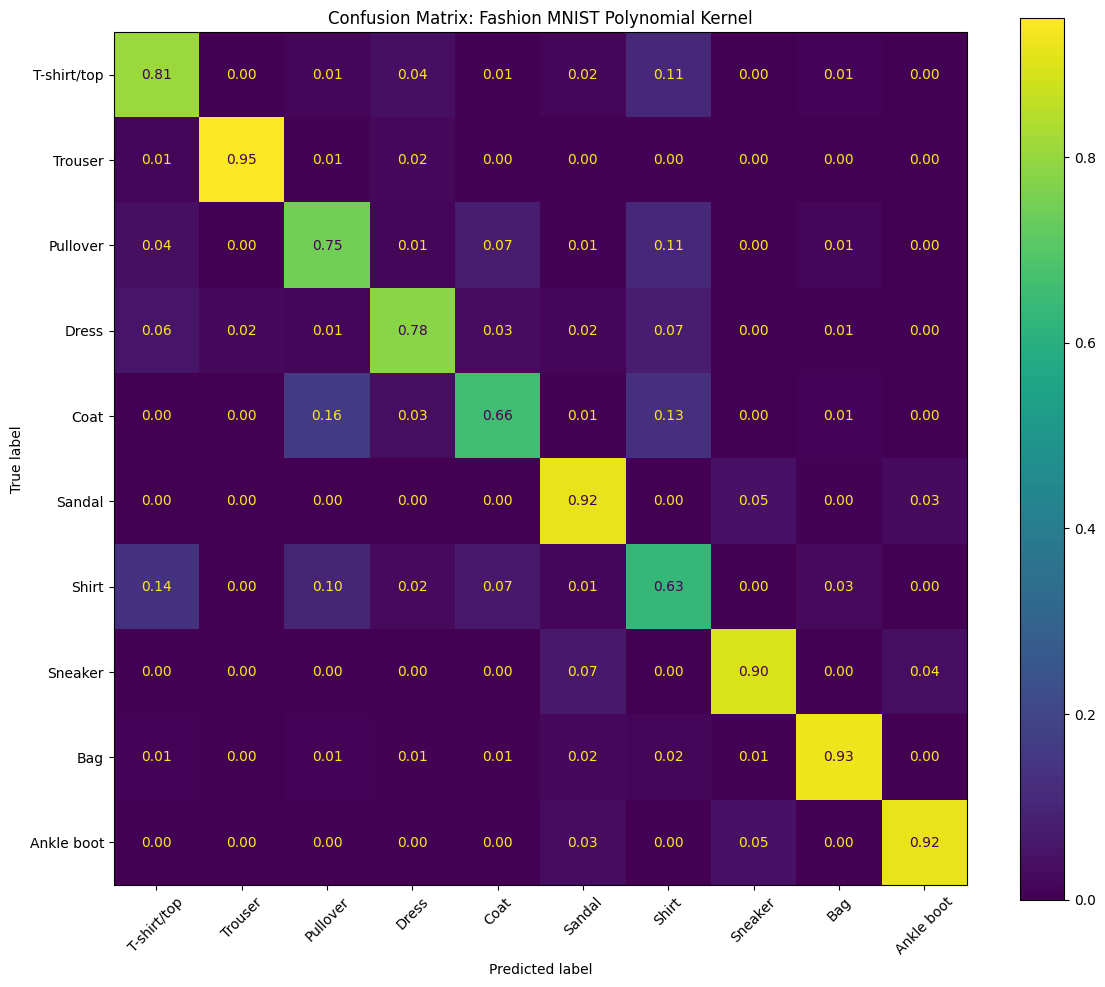

Train Accuracy:  0.9763
Test Accuracy:   0.8238
Overfitting Gap: 0.1525
Training Time:   0:00:06.156990

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.81      0.78      1000
     Trouser       0.98      0.95      0.96      1000
    Pullover       0.71      0.75      0.73      1000
       Dress       0.85      0.78      0.81      1000
        Coat       0.78      0.66      0.72      1000
      Sandal       0.84      0.92      0.87      1000
       Shirt       0.59      0.63      0.61      1000
     Sneaker       0.90      0.90      0.90      1000
         Bag       0.93      0.93      0.93      1000
  Ankle boot       0.93      0.92      0.93      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



In [23]:
# Polynomial kernel has parameters C (regularization) and degree. Gamma is usually set to 'scale' by default.
C_values = [0.1, 1, 10]
degree_values = [3, 4, 5]
poly_results = []

print("── Polynomial Kernel Grid Search ──")
# Perform grid search for the Polynomial kernel
for C in C_values:
    for degree in degree_values:
        # Initialize SVM classifier with polynomial kernel and current parameters
        clf = svm.SVC(kernel='poly', C=C, gamma='scale', degree=degree)

        start = time.time() # Start time for training
        clf.fit(x_train_mini, y_train_mini) # Train the classifier on the mini dataset
        train_time = time.time() - start # Calculate training time

        train_acc = clf.score(x_train_mini, y_train_mini) # Calculate training accuracy
        test_acc  = clf.score(x_test, y_test) # Calculate test accuracy

        # Store the results for the current C and degree values
        result = {
            'C': C,
            'degree': degree,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'overfit_gap': train_acc - test_acc,
            'time': train_time
        }
        poly_results.append(result)
        print(f"  C={C:<4} degree={degree}  →  "
              f"train={train_acc:.4f}  test={test_acc:.4f}  "
              f"gap={train_acc - test_acc:.4f}  time={train_time:.1f}s")

# Sigmoid Kernel


── Sigmoid Kernel Grid Search ──
  C=0.1  coef0=0.0  →  train=0.4300  test=0.4299  gap=0.0001  time=11.9s
  C=0.1  coef0=0.5  →  train=0.4865  test=0.4800  gap=0.0065  time=14.1s
  C=0.1  coef0=1.0  →  train=0.4762  test=0.4624  gap=0.0138  time=17.3s
  C=1    coef0=0.0  →  train=0.3875  test=0.4025  gap=-0.0150  time=7.9s
  C=1    coef0=0.5  →  train=0.3400  test=0.3510  gap=-0.0110  time=12.2s
  C=1    coef0=1.0  →  train=0.3450  test=0.3576  gap=-0.0126  time=12.7s
  C=10   coef0=0.0  →  train=0.3675  test=0.3791  gap=-0.0116  time=7.0s
  C=10   coef0=0.5  →  train=0.3202  test=0.3395  gap=-0.0193  time=8.9s
  C=10   coef0=1.0  →  train=0.2817  test=0.2974  gap=-0.0157  time=11.1s

Best Sigmoid config: {'C': 0.1, 'coef0': 0.5, 'train_acc': 0.4865, 'test_acc': 0.48, 'overfit_gap': 0.006500000000000006, 'time': 14.101951837539673}

Started training at 2026-03-16 18:51:33.487737
Training complete. Elapsed time: 0:00:18.164354
Prediction elapsed time: 0:01:02.218188


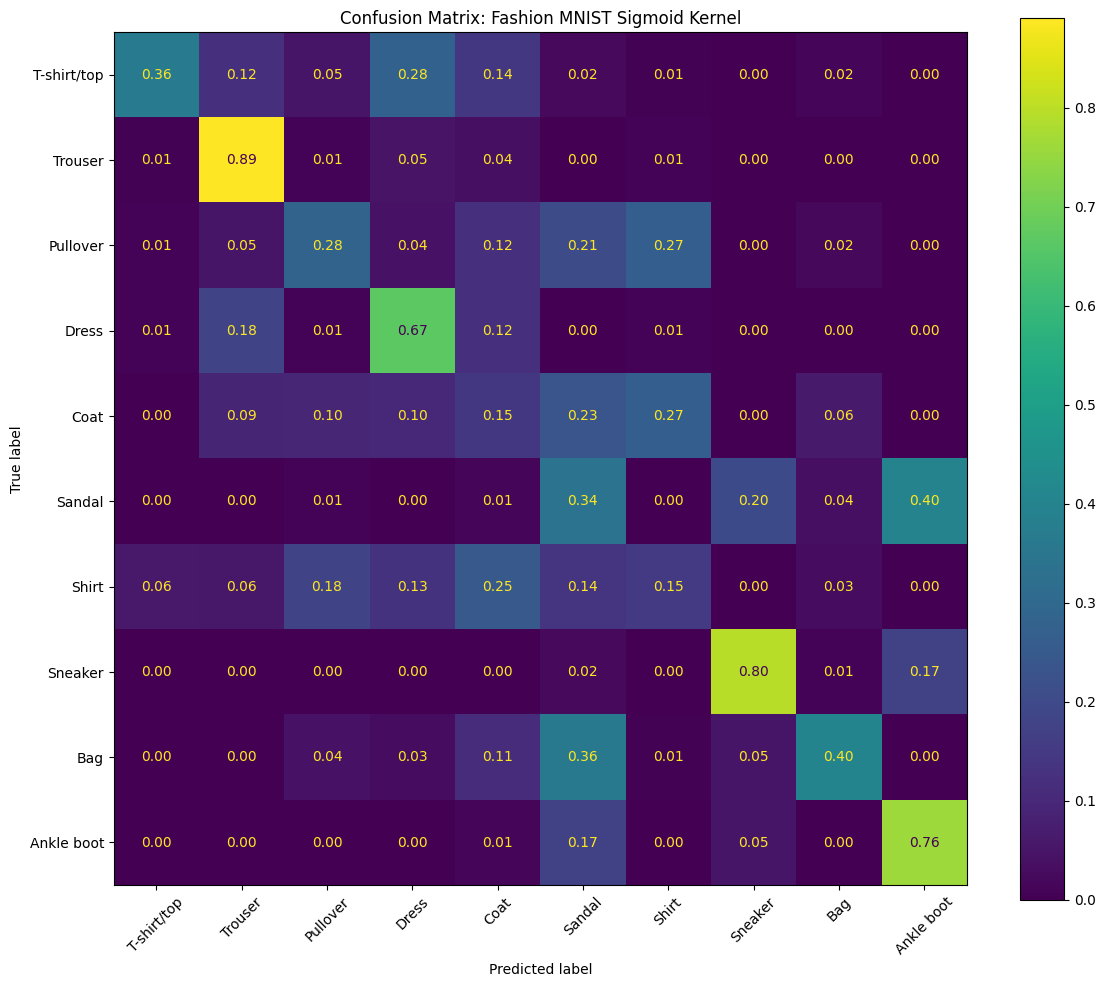

Train Accuracy:  0.4865
Test Accuracy:   0.4800
Overfitting Gap: 0.0065
Training Time:   0:00:18.164354

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.36      0.50      1000
     Trouser       0.64      0.89      0.74      1000
    Pullover       0.41      0.28      0.34      1000
       Dress       0.51      0.67      0.58      1000
        Coat       0.15      0.15      0.15      1000
      Sandal       0.23      0.34      0.27      1000
       Shirt       0.21      0.15      0.18      1000
     Sneaker       0.73      0.80      0.76      1000
         Bag       0.70      0.40      0.51      1000
  Ankle boot       0.57      0.76      0.65      1000

    accuracy                           0.48     10000
   macro avg       0.50      0.48      0.47     10000
weighted avg       0.50      0.48      0.47     10000



In [16]:
print("\n── Sigmoid Kernel Grid Search ──")

# Sigmoid kernel: K(x, y) = tanh(gamma * x·y + coef0)
# Key params: C (regularisation), gamma (scale of dot product), coef0 (bias term)

C_values     = [0.1, 1, 10]
coef0_values = [0.0, 0.5, 1.0]   # bias term; 0 = passing through origin

sigmoid_results = []

# Perform grid search for the Sigmoid kernel
for C in C_values:
    for coef0 in coef0_values:
        # Initialize SVM classifier with sigmoid kernel and current parameters
        clf = svm.SVC(kernel='sigmoid', C=C, gamma='scale', coef0=coef0)

        start = time.time() # Start time for training
        clf.fit(x_train_mini, y_train_mini) # Train the classifier on the mini dataset
        train_time = time.time() - start # Calculate training time

        train_acc = clf.score(x_train_mini, y_train_mini) # Calculate training accuracy
        test_acc  = clf.score(x_test, y_test) # Calculate test accuracy

        # Store the results for the current C and coef0 values
        result = {
            'C':          C,
            'coef0':      coef0,
            'train_acc':  train_acc,
            'test_acc':   test_acc,
            'overfit_gap': train_acc - test_acc,
            'time':       train_time
        }
        sigmoid_results.append(result)
        print(f"  C={C:<4} coef0={coef0}  →  "
              f"train={train_acc:.4f}  test={test_acc:.4f}  "
              f"gap={train_acc - test_acc:.4f}  time={train_time:.1f}s")